<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [2]:
# Step 2: Examine the Structure of the Data

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nSummary info:")
print(df.info())

print("\nFirst 5 rows:")
print(df.head())

Shape of dataset: (65437, 114)

Column names:
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHave

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [3]:
# Step 3: Handle Missing Data

print("Missing values before handling:")
print(df.isnull().sum().sort_values(ascending=False))

# Fill important categorical columns with mode
for col in ['Employment', 'JobSat', 'RemoteWork', 'EdLevel']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# Fill YearsCodePro carefully
if 'YearsCodePro' in df.columns:
    df['YearsCodePro'] = df['YearsCodePro'].fillna(df['YearsCodePro'].mode()[0])

# Fill language columns with empty string for easier splitting later
for col in ['LanguageHaveWorkedWith', 'LanguageWantToWorkWith']:
    if col in df.columns:
        df[col] = df[col].fillna('')

print("\nMissing values after handling:")
print(df.isnull().sum().sort_values(ascending=False))

Missing values before handling:
AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
MainBranch                        0
Check                             0
Employment                        0
Age                               0
ResponseId                        0
Length: 114, dtype: int64

Missing values after handling:
AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
Check                             0
RemoteWork                        0
Employment                        0
Age                               0
JobSat                            0
Length: 114, dtype: int64


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [4]:
# Step 4: Analyze Key Columns

print("Employment value counts:")
print(df['Employment'].value_counts())

print("\nJobSat value counts:")
print(df['JobSat'].value_counts())

print("\nYearsCodePro value counts:")
print(df['YearsCodePro'].value_counts())

Employment value counts:
Employment
Employed, full-time                                                                                                                                  39041
Independent contractor, freelancer, or self-employed                                                                                                  4846
Student, full-time                                                                                                                                    4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                              3557
Not employed, but looking for work                                                                                                                    2341
                                                                                                                                                     ...  
Employed, full-time;Student, full-

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


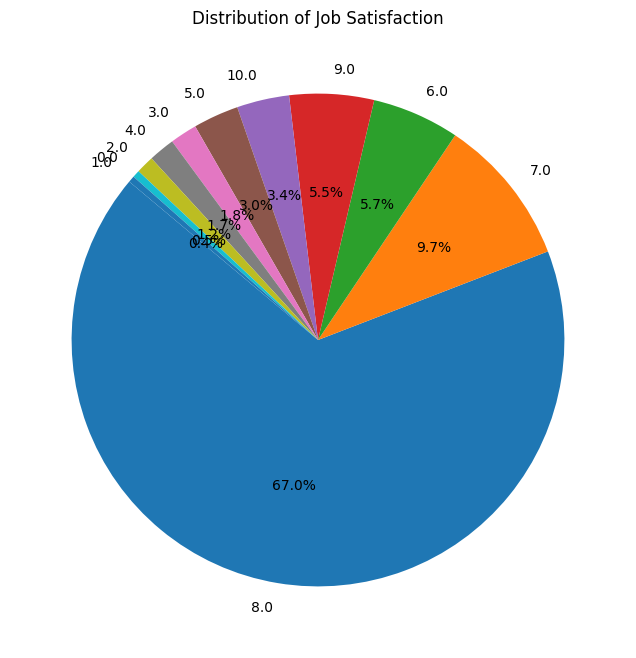

In [5]:
# Step 5: Visualize Job Satisfaction (Pie Chart)

jobsat_counts = df['JobSat'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(jobsat_counts, labels=jobsat_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Job Satisfaction')
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


                         HaveWorkedWith  WantToWorkWith
JavaScript                        37492           23774
HTML/CSS                          31816           20721
Python                            30719           25047
SQL                               30682           22400
TypeScript                        23150           20239
Bash/Shell (all shells)           20412           13744
Java                              18239           10668
C#                                16318           12921
C++                               13827           10873
C                                 12184            8275
Go                                 8103           13837
Rust                               7559           17232


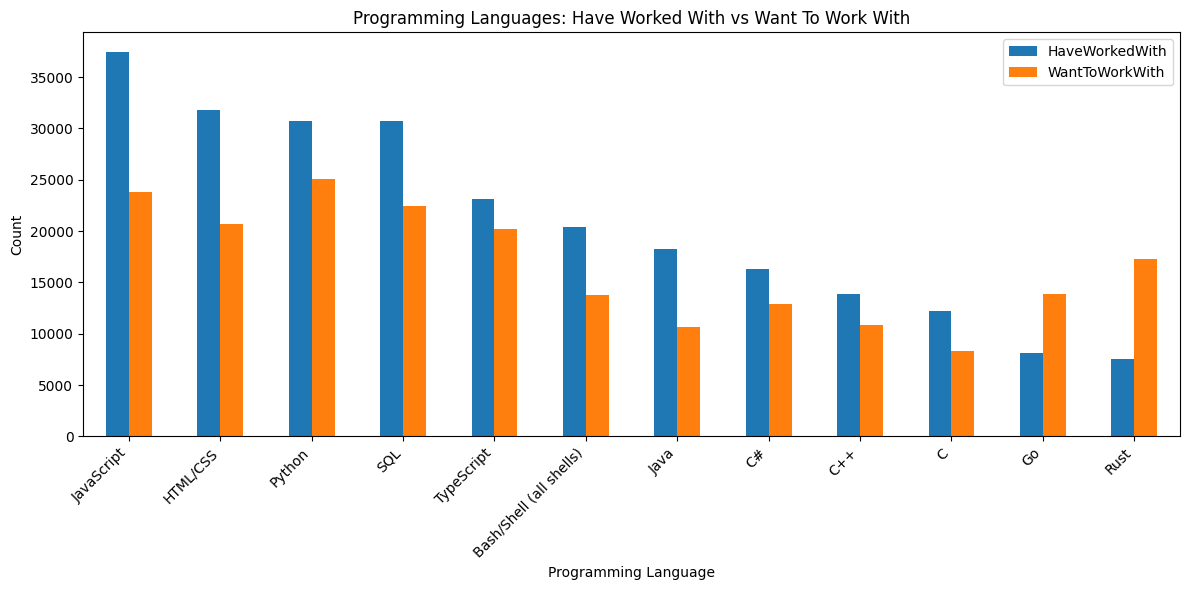

In [6]:
# Step 6: Programming Languages Analysis

have_lang = df['LanguageHaveWorkedWith'].str.split(';').explode().str.strip()
want_lang = df['LanguageWantToWorkWith'].str.split(';').explode().str.strip()

have_counts = have_lang[have_lang != ''].value_counts().head(10)
want_counts = want_lang[want_lang != ''].value_counts().head(10)

top_languages = list(set(have_counts.index).union(set(want_counts.index)))

lang_compare = pd.DataFrame({
    'HaveWorkedWith': have_lang[have_lang.isin(top_languages)].value_counts(),
    'WantToWorkWith': want_lang[want_lang.isin(top_languages)].value_counts()
}).fillna(0)

lang_compare = lang_compare.sort_values('HaveWorkedWith', ascending=False)

print(lang_compare)

lang_compare.plot(kind='bar', figsize=(12, 6))
plt.title('Programming Languages: Have Worked With vs Want To Work With')
plt.xlabel('Programming Language')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


RemoteWork                                          Hybrid (some remote, some in-person)  \
Country                                                                                    
Brazil                                                                               470   
Canada                                                                               970   
France                                                                              1344   
Germany                                                                             3098   
India                                                                               2290   
Netherlands                                                                         1028   
Poland                                                                               686   
Ukraine                                                                              828   
United Kingdom of Great Britain and Northern Ir...                              

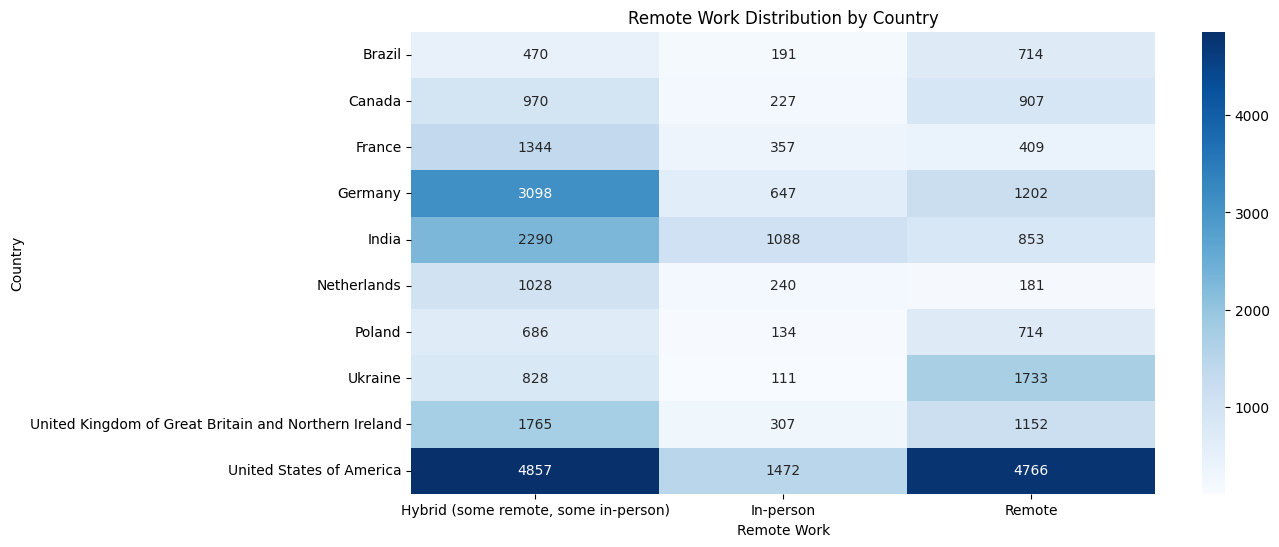

In [7]:
# Step 7: Analyze Remote Work Trends
# Using Country as a region proxy

top_countries = df['Country'].value_counts().head(10).index
remote_region = pd.crosstab(
    df[df['Country'].isin(top_countries)]['Country'],
    df[df['Country'].isin(top_countries)]['RemoteWork']
)

print(remote_region)

plt.figure(figsize=(12, 6))
sns.heatmap(remote_region, annot=True, fmt='d', cmap='Blues')
plt.title('Remote Work Distribution by Country')
plt.xlabel('Remote Work')
plt.ylabel('Country')
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


Pearson correlation: nan


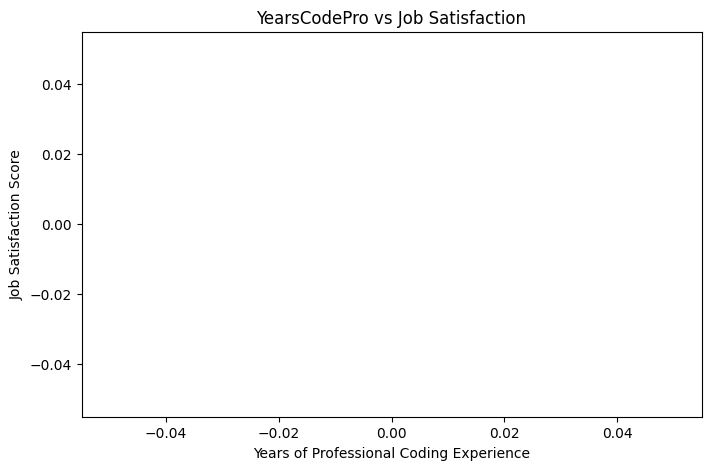

In [9]:
# Step 8: Correlation between Job Satisfaction and Experience

def convert_years(value):
    if pd.isna(value):
        return float('nan')
    value = str(value).strip()
    if value == 'Less than 1 year':
        return 0.5
    elif value == 'More than 50 years':
        return 51
    else:
        return pd.to_numeric(value, errors='coerce')

df['YearsCodePro_num'] = df['YearsCodePro'].apply(convert_years)

jobsat_order = [
    'Very dissatisfied',
    'Slightly dissatisfied',
    'Neither satisfied nor dissatisfied',
    'Slightly satisfied',
    'Very satisfied'
]

jobsat_map = {label: i + 1 for i, label in enumerate(jobsat_order)}
df['JobSat_num'] = df['JobSat'].map(jobsat_map)

corr_data = df[['YearsCodePro_num', 'JobSat_num']].dropna()

pearson_corr = corr_data['YearsCodePro_num'].corr(corr_data['JobSat_num'])

print("Pearson correlation:", pearson_corr)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=corr_data, x='YearsCodePro_num', y='JobSat_num')
plt.title('YearsCodePro vs Job Satisfaction')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Job Satisfaction Score')
plt.show()

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


EdLevel                                             Associate degree (A.A., A.S., etc.)  \
Employment                                                                                
Employed, full-time                                                                1059   
Employed, full-time;Employed, part-time                                               9   
Employed, full-time;Independent contractor, fre...                                  104   
Employed, full-time;Independent contractor, fre...                                   11   
Employed, full-time;Independent contractor, fre...                                    0   
...                                                                                 ...   
Student, full-time;Student, part-time;Employed,...                                    0   
Student, full-time;Student, part-time;Retired                                         0   
Student, part-time                                                                   12   

C:\Users\rushi\AppData\Local\Temp\ipykernel_31408\1263739324.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


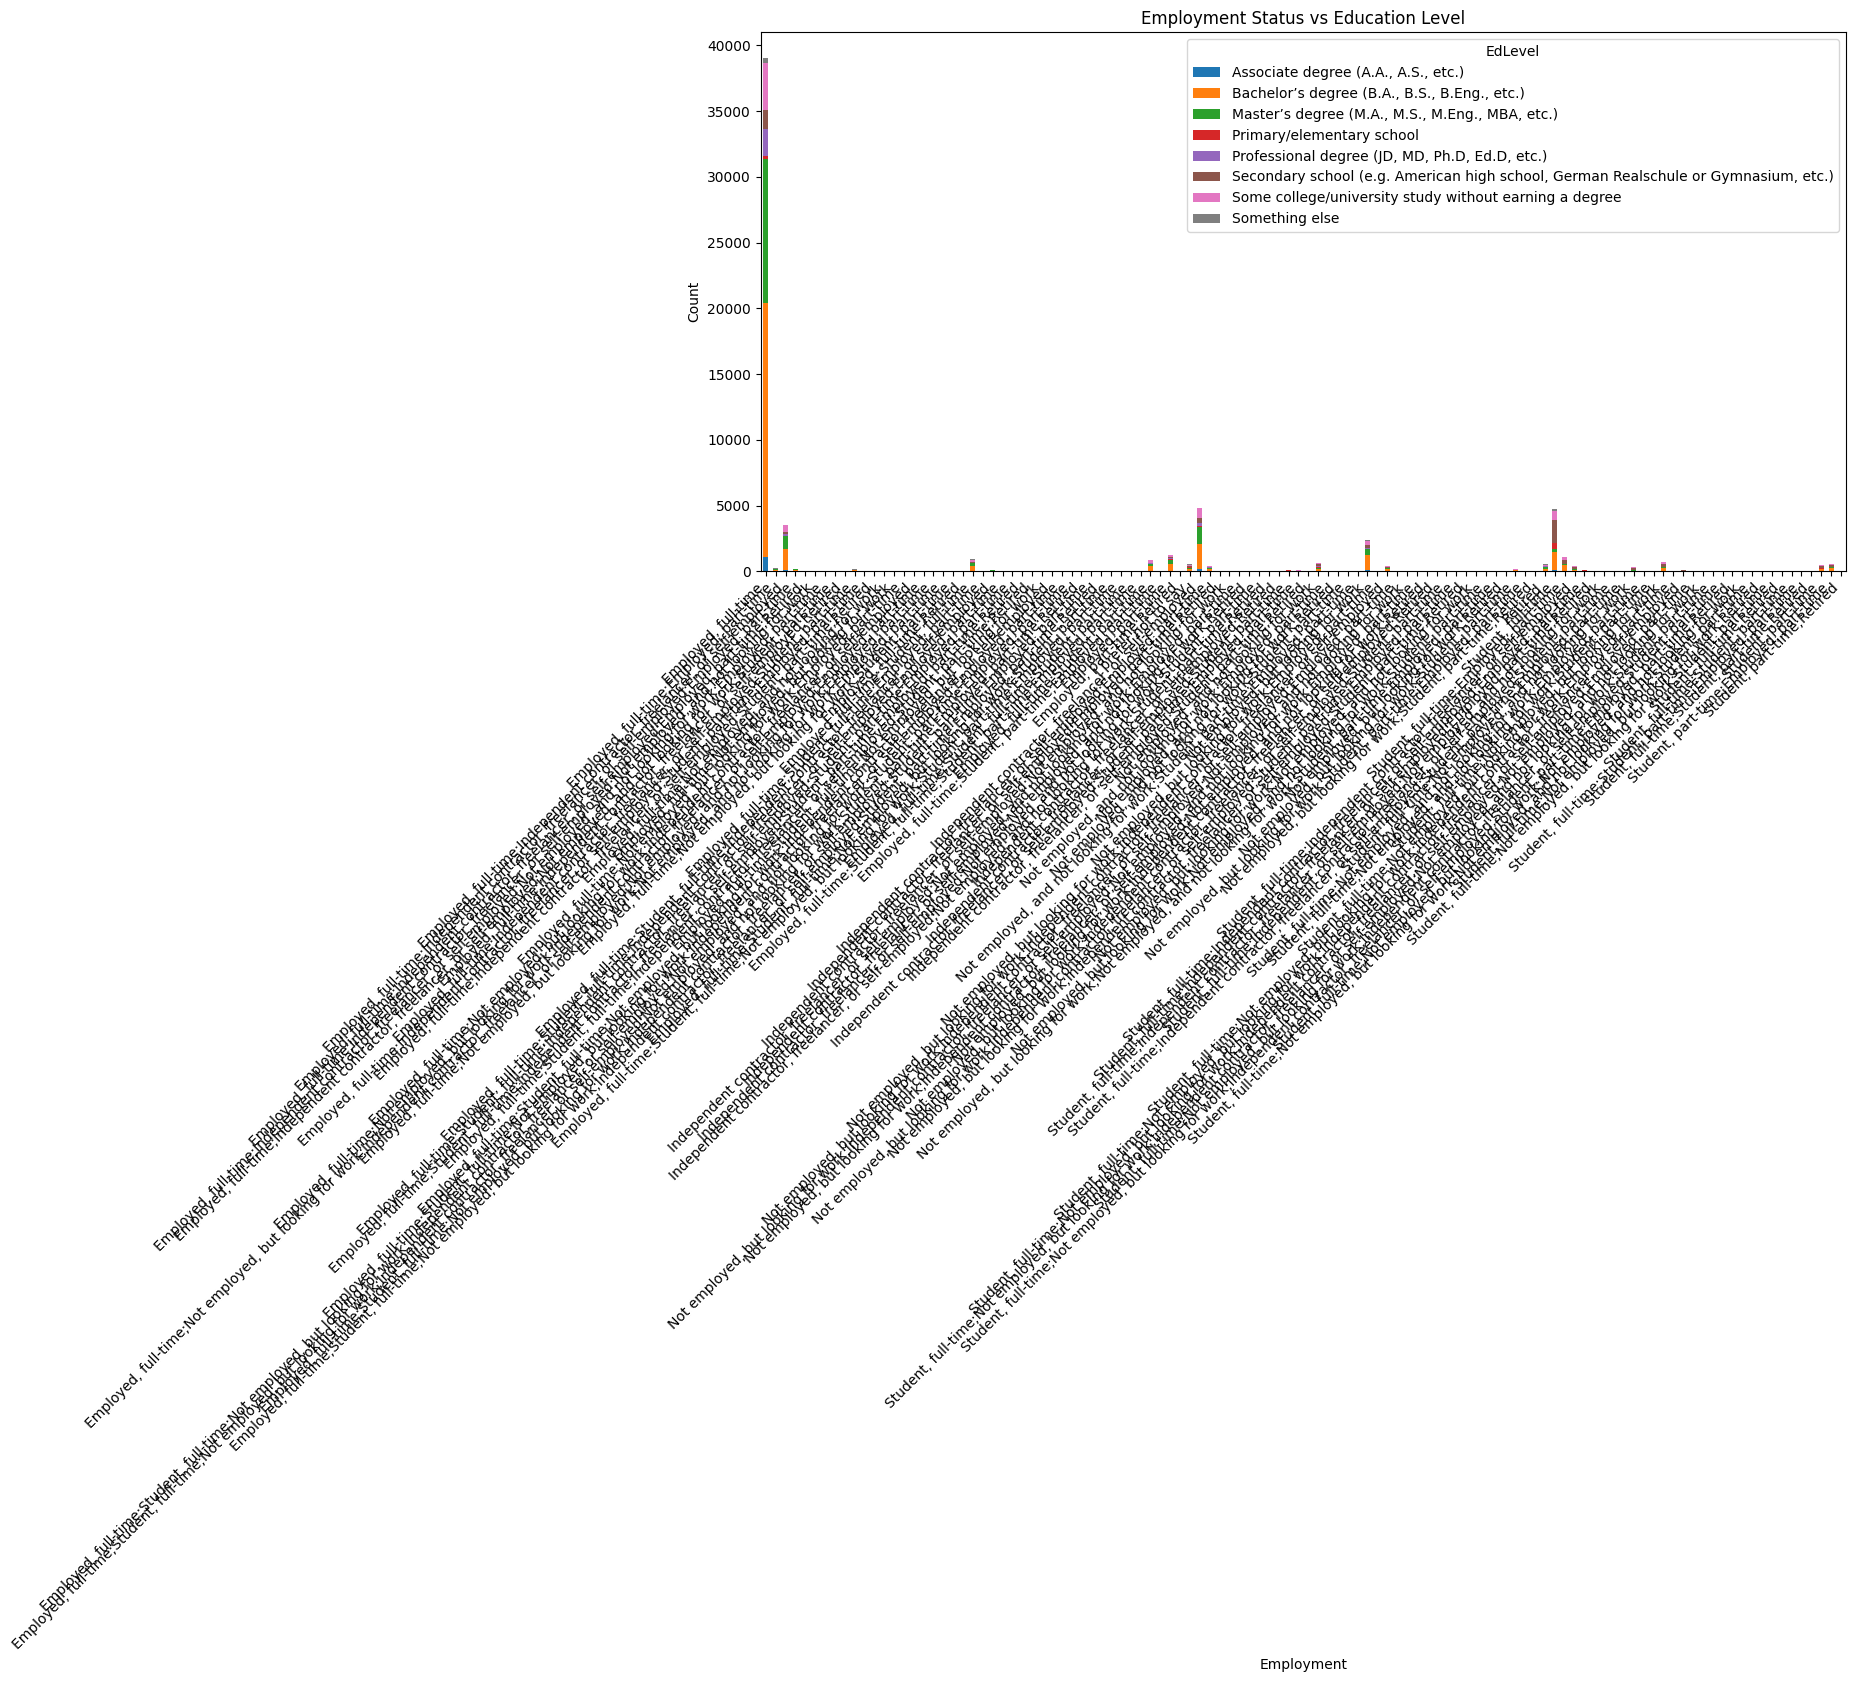

In [10]:
# Step 9: Cross-tabulation Analysis (Employment vs Education Level)

emp_ed_ct = pd.crosstab(df['Employment'], df['EdLevel'])
print(emp_ed_ct)

emp_ed_ct.plot(kind='bar', stacked=True, figsize=(14, 7))
plt.title('Employment Status vs Education Level')
plt.xlabel('Employment')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [11]:
# Step 10: Export Cleaned Data

df.to_csv('cleaned_stackoverflow_survey.csv', index=False)
print("Cleaned dataset saved as cleaned_stackoverflow_survey.csv")

Cleaned dataset saved as cleaned_stackoverflow_survey.csv


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
